# Detección de contornos

En este cuaderno vas a estudiar cómo una región binaria se convierte en un borde que OpenCV puede recorrer y dibujar. Primero vamos a usar formas simples y después vamos a transferir la idea a una imagen real.


## Objetivo

Entender el pasaje máscara -> contorno y reconocer por qué la calidad de la máscara condiciona completamente el resultado final.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- construir una máscara binaria controlada;
- usar `cv2.findContours()` para recuperar bordes;
- filtrar contornos por área;
- transferir el procedimiento a una imagen real segmentada por color.

## Relación con la secuencia

Este cuaderno prepara el terreno para medir propiedades geométricas. Antes de hablar de área, perímetro o centroides, conviene entender de dónde sale exactamente el contorno.


## Módulos que vamos a usar

- `cv2`: para construir máscaras, encontrar contornos y dibujarlos.
- `numpy`: para crear imágenes binarias simples.
- `matplotlib.pyplot`: para visualizar cada etapa.
- `pathlib.Path`: para abrir la imagen real de transferencia.


In [ ]:
# Importamos Path para construir rutas de archivos de manera clara.
from pathlib import Path

# Importamos OpenCV para construir mascaras, detectar contornos y dibujarlos.
import cv2

# Importamos NumPy para crear imagenes binarias sinteticas.
import numpy as np

# Importamos Matplotlib para mostrar cada etapa del proceso.
import matplotlib.pyplot as plt


## 1. Empezar con una máscara simple

Cuando el objetivo es entender cómo funciona `findContours`, conviene empezar con una imagen binaria controlada. Así el foco queda en el mecanismo y no en errores previos de segmentación.


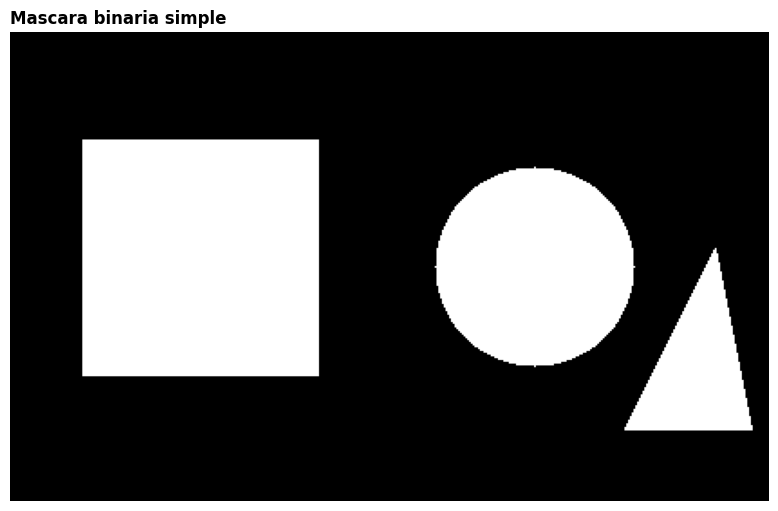

In [ ]:
# Creamos una mascara negra que funcionara como lienzo binario.
mascara_simple = np.zeros((260, 420), dtype=np.uint8)

# Dibujamos tres formas blancas para tener regiones bien definidas.
cv2.rectangle(mascara_simple, (40, 60), (170, 190), 255, -1)
cv2.circle(mascara_simple, (290, 130), 55, 255, -1)
puntos_triangulo = np.array([[340, 220], [390, 120], [410, 220]], dtype=np.int32)
cv2.fillPoly(mascara_simple, [puntos_triangulo], 255)

# Mostramos la mascara antes de extraer contornos.
plt.figure(figsize=(8, 5), constrained_layout=True)
plt.imshow(mascara_simple, cmap="gray")
plt.title("Mascara binaria simple", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


## 2. Encontrar y dibujar contornos

`cv2.findContours()` no devuelve una imagen lista. Devuelve una lista de curvas. Después nosotros decidimos cómo mostrarlas.


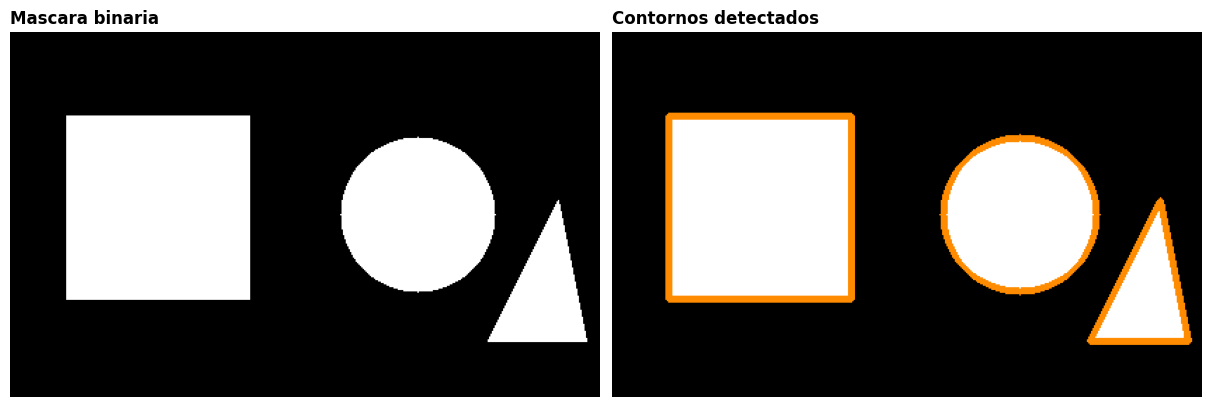

Cantidad de contornos detectados: 3


In [ ]:
# findContours recorre el borde de cada region blanca externa.
contornos_simples, _ = cv2.findContours(mascara_simple.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Convertimos a RGB para dibujar los contornos con color.
imagen_contornos_simple = cv2.cvtColor(mascara_simple, cv2.COLOR_GRAY2RGB)
cv2.drawContours(imagen_contornos_simple, contornos_simples, -1, (255, 140, 0), 3)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ejes[0].imshow(mascara_simple, cmap="gray")
ejes[0].set_title("Mascara binaria", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_contornos_simple)
ejes[1].set_title("Contornos detectados", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

print(f"Cantidad de contornos detectados: {len(contornos_simples)}")


En este ejemplo la relación entre máscara y contorno es directa. Eso ayuda a entender que el contorno no “descubre” el objeto por sí solo: sigue el borde de lo que la máscara ya definió como región blanca.


## 3. Transferir la idea a una imagen real

Ahora vamos a pasar a una imagen de globos. En este caso, primero necesitamos construir una máscara de color y después recién buscar los contornos.


In [ ]:
# Leemos la imagen real de globos.
ruta_globos = Path("Imagenes") / "globos.jpg"
imagen_globos_bgr = cv2.imread(str(ruta_globos), cv2.IMREAD_COLOR)
if imagen_globos_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_globos}")

# Preparamos versiones RGB y HSV para visualizar y segmentar por color.
imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB)
imagen_globos_hsv = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2HSV)

# Definimos un rango naranja inicial.
rango_naranja_bajo = np.array([8, 80, 80], dtype=np.uint8)
rango_naranja_alto = np.array([22, 255, 255], dtype=np.uint8)

# inRange construye una mascara binaria con los pixeles dentro del rango.
mascara_naranja = cv2.inRange(imagen_globos_hsv, rango_naranja_bajo, rango_naranja_alto)

# Una apertura elimina pequenos puntos aislados antes de buscar contornos.
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8), iterations=1)
mascara_naranja


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1024, 1024), dtype=uint8)

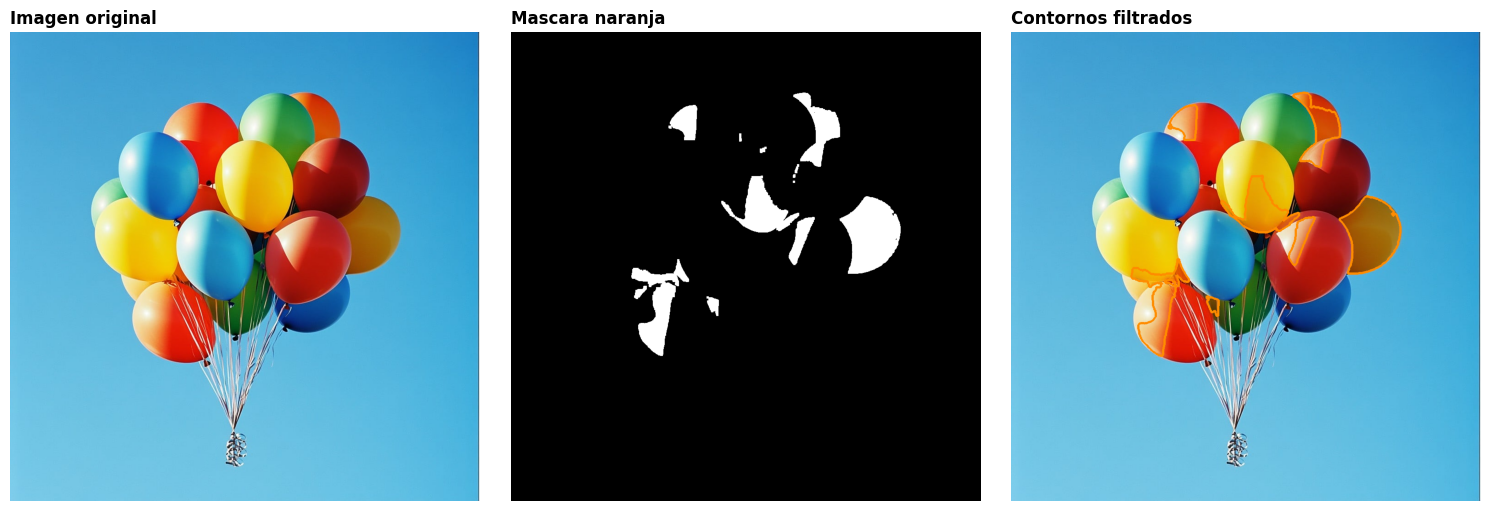

Contornos detectados antes del filtro: 13
Contornos conservados despues del filtro: 7


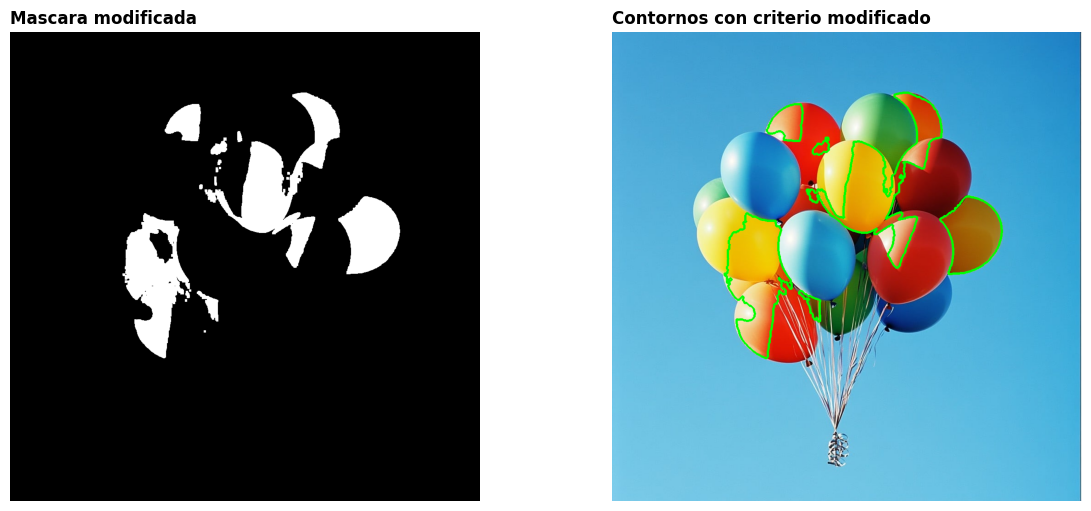

Contornos modificados conservados: 6


In [ ]:
# Extraemos contornos de la mascara segmentada.
contornos_reales, _ = cv2.findContours(mascara_naranja.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filtramos regiones muy chicas para reducir contornos poco relevantes.
contornos_filtrados = []
for contorno in contornos_reales:
    if cv2.contourArea(contorno) > 500:
        contornos_filtrados.append(contorno)

# Dibujamos los contornos conservados sobre la imagen original.
imagen_con_contornos = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos, contornos_filtrados, -1, (255, 140, 0), 3)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_globos_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_naranja, cmap="gray")
ejes[1].set_title("Mascara naranja", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_con_contornos)
ejes[2].set_title("Contornos filtrados", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

print(f"Contornos detectados antes del filtro: {len(contornos_reales)}")
print(f"Contornos conservados despues del filtro: {len(contornos_filtrados)}")

# Actividad extendida: probamos un rango mas amplio y un area minima menor.
rango_naranja_bajo_alt = np.array([5, 60, 60], dtype=np.uint8)
rango_naranja_alto_alt = np.array([25, 255, 255], dtype=np.uint8)
mascara_naranja_alt = cv2.inRange(imagen_globos_hsv, rango_naranja_bajo_alt, rango_naranja_alto_alt)
mascara_naranja_alt = cv2.morphologyEx(mascara_naranja_alt, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8), iterations=1)
contornos_alt, _ = cv2.findContours(mascara_naranja_alt.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_filtrados_alt = [c for c in contornos_alt if cv2.contourArea(c) > 250]
imagen_con_contornos_alt = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos_alt, contornos_filtrados_alt, -1, (0, 255, 0), 3)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(mascara_naranja_alt, cmap="gray")
ejes[0].set_title("Mascara modificada", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_con_contornos_alt)
ejes[1].set_title("Contornos con criterio modificado", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()
print(f"Contornos modificados conservados: {len(contornos_filtrados_alt)}")


Fijate que la calidad del contorno depende totalmente de la máscara. Si la segmentación deja ruido o se come partes del objeto, el contorno también queda mal. Por eso conviene pensar estas etapas como una cadena y no como funciones aisladas.


## Actividad breve

Modifica el rango de color o el criterio de area minima y volve a ejecutar el proceso. Despues explica:

1. que cambio en la mascara;
2. que cambio en los contornos detectados;
3. cual seria un criterio razonable para decidir si un contorno vale la pena conservar.

### Respuesta propuesta

1. Al ampliar el rango de color, la mascara incluyo mas pixeles anaranjados y tambien algunas zonas menos puras del mismo color.
2. Al bajar el area minima, aparecieron mas contornos conservados, incluidos algunos pequenos que antes se descartaban.
3. Un criterio razonable es conservar contornos con area suficiente, forma coherente con el objeto buscado y estabilidad al cambiar levemente los parametros.


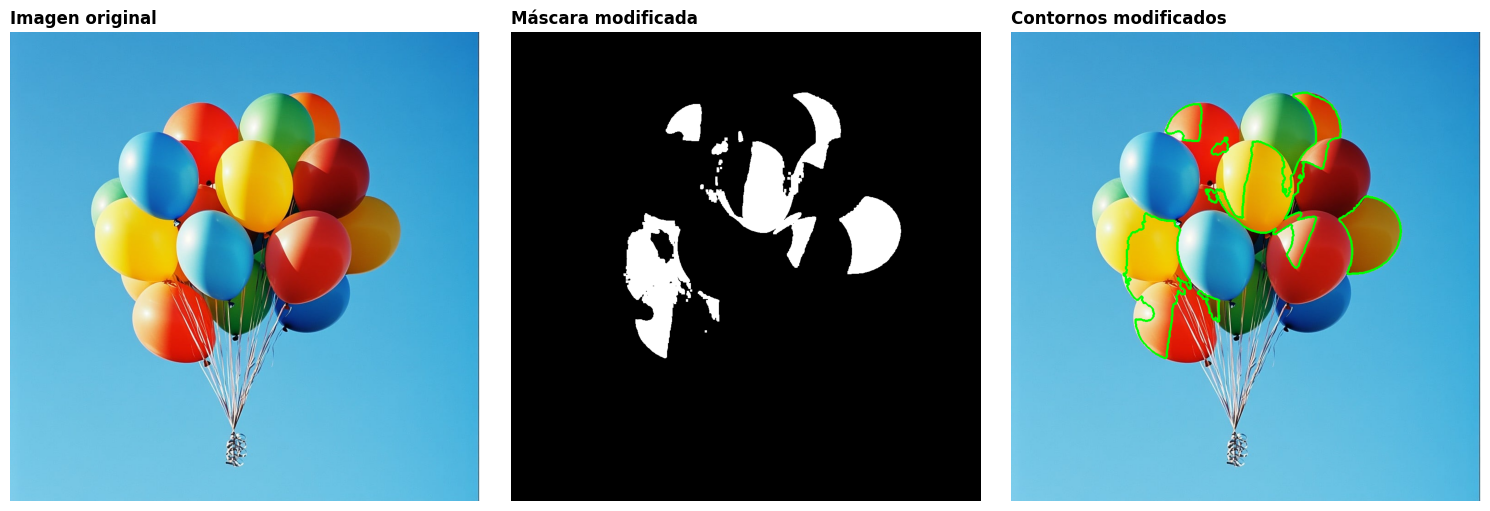

Contornos detectados con el nuevo rango: 18
Contornos conservados con área mínima 250: 6


In [ ]:
# Nuevo rango de color: un poco más amplio que el original
rango_naranja_bajo_nuevo = np.array([5, 60, 60], dtype=np.uint8)
rango_naranja_alto_nuevo = np.array([25, 255, 255], dtype=np.uint8)

# Nueva máscara con el rango modificado
mascara_naranja_nueva = cv2.inRange(
    imagen_globos_hsv,
    rango_naranja_bajo_nuevo,
    rango_naranja_alto_nuevo
)

# Limpieza morfológica igual que en el caso base
mascara_naranja_nueva = cv2.morphologyEx(
    mascara_naranja_nueva,
    cv2.MORPH_OPEN,
    np.ones((5, 5), dtype=np.uint8),
    iterations=1
)

# Nuevos contornos detectados
contornos_nuevos, _ = cv2.findContours(
    mascara_naranja_nueva.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Nuevo criterio de área mínima: más flexible
area_minima_nueva = 250

contornos_filtrados_nuevos = []
for contorno in contornos_nuevos:
    if cv2.contourArea(contorno) > area_minima_nueva:
        contornos_filtrados_nuevos.append(contorno)

# Dibujo de resultados
imagen_con_contornos_nuevos = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos_nuevos, contornos_filtrados_nuevos, -1, (0, 255, 0), 3)

# Comparación visual
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ejes[0].imshow(imagen_globos_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(mascara_naranja_nueva, cmap="gray")
ejes[1].set_title("Máscara modificada", fontweight="bold", loc="left")
ejes[1].axis("off")

ejes[2].imshow(imagen_con_contornos_nuevos)
ejes[2].set_title("Contornos modificados", fontweight="bold", loc="left")
ejes[2].axis("off")

plt.show()

print(f"Contornos detectados con el nuevo rango: {len(contornos_nuevos)}")
print(f"Contornos conservados con área mínima {area_minima_nueva}: {len(contornos_filtrados_nuevos)}")


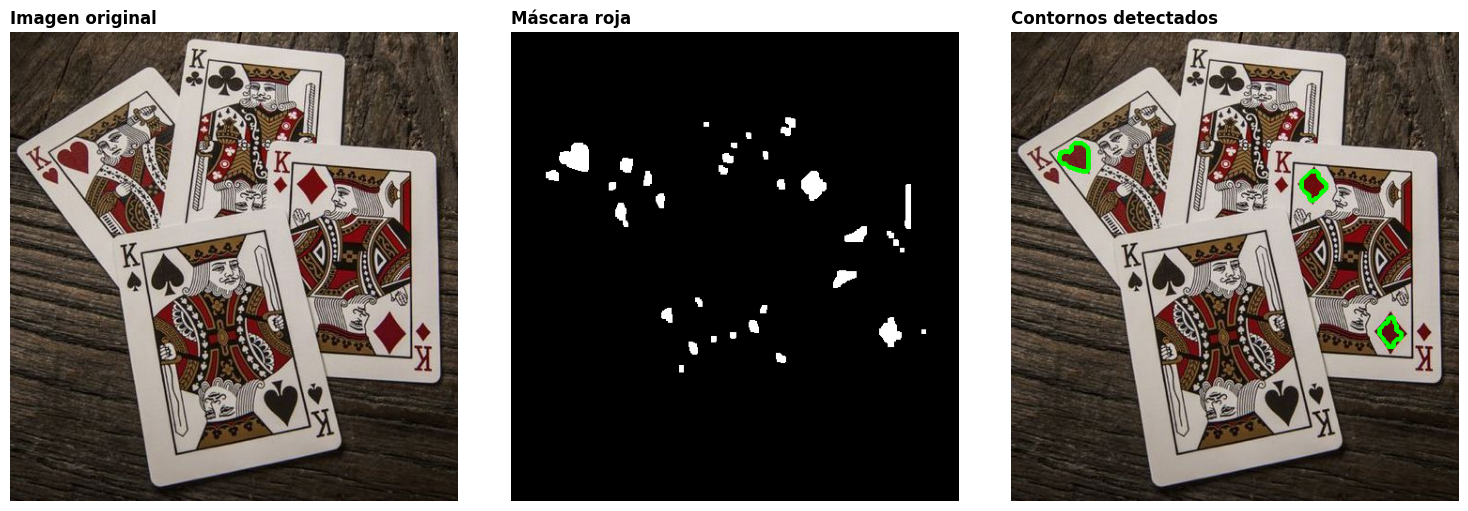

Contornos detectados antes del filtro: 33
Contornos conservados con área mínima 300: 3


In [ ]:
# Cargar la imagen de las cartas
ruta_cards = Path("Imagenes") / "cards.jpg"
imagen_cards_bgr = cv2.imread(str(ruta_cards), cv2.IMREAD_COLOR)

if imagen_cards_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_cards}")

# Convertir para visualización y segmentación
imagen_cards_rgb = cv2.cvtColor(imagen_cards_bgr, cv2.COLOR_BGR2RGB)
imagen_cards_hsv = cv2.cvtColor(imagen_cards_bgr, cv2.COLOR_BGR2HSV)

# Rango rojo en HSV
# El rojo suele necesitar dos rangos porque está en los extremos del canal H
rango_rojo_bajo_1 = np.array([0, 80, 80], dtype=np.uint8)
rango_rojo_alto_1 = np.array([10, 255, 255], dtype=np.uint8)

rango_rojo_bajo_2 = np.array([170, 80, 80], dtype=np.uint8)
rango_rojo_alto_2 = np.array([180, 255, 255], dtype=np.uint8)

# Crear máscara para ambos rangos y combinarlas
mascara_roja_1 = cv2.inRange(imagen_cards_hsv, rango_rojo_bajo_1, rango_rojo_alto_1)
mascara_roja_2 = cv2.inRange(imagen_cards_hsv, rango_rojo_bajo_2, rango_rojo_alto_2)
mascara_roja = cv2.bitwise_or(mascara_roja_1, mascara_roja_2)

# Limpieza morfológica
mascara_roja = cv2.morphologyEx(
    mascara_roja,
    cv2.MORPH_OPEN,
    np.ones((5, 5), dtype=np.uint8),
    iterations=1
)

# Buscar contornos
contornos_cards, _ = cv2.findContours(
    mascara_roja.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Filtrar por área mínima
area_minima = 300
contornos_filtrados_cards = []

for contorno in contornos_cards:
    if cv2.contourArea(contorno) > area_minima:
        contornos_filtrados_cards.append(contorno)

# Dibujar contornos sobre la imagen original
imagen_con_contornos_cards = imagen_cards_rgb.copy()
cv2.drawContours(imagen_con_contornos_cards, contornos_filtrados_cards, -1, (0, 255, 0), 3)

# Mostrar resultados
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ejes[0].imshow(imagen_cards_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(mascara_roja, cmap="gray")
ejes[1].set_title("Máscara roja", fontweight="bold", loc="left")
ejes[1].axis("off")

ejes[2].imshow(imagen_con_contornos_cards)
ejes[2].set_title("Contornos detectados", fontweight="bold", loc="left")
ejes[2].axis("off")

plt.show()

print(f"Contornos detectados antes del filtro: {len(contornos_cards)}")
print(f"Contornos conservados con área mínima {area_minima}: {len(contornos_filtrados_cards)}")


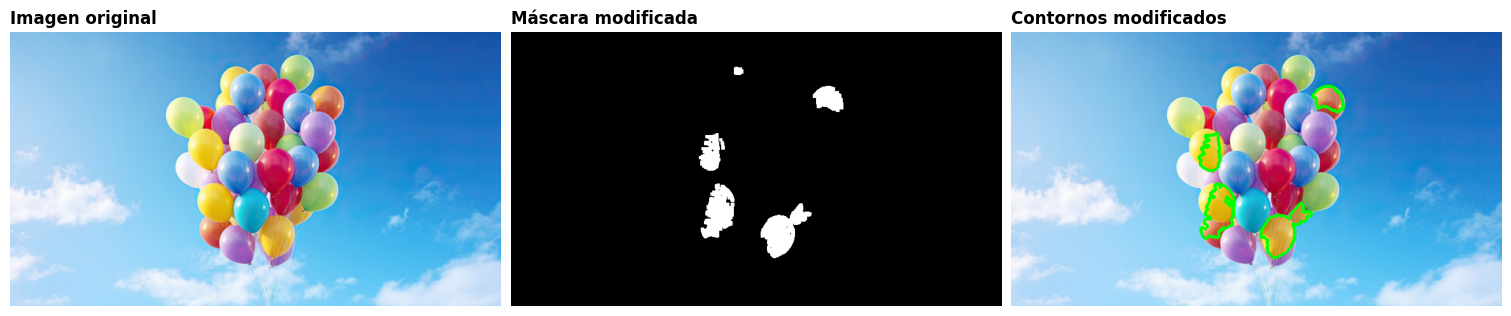

Contornos detectados con el nuevo rango: 6
Contornos conservados con área mínima 250: 4


In [ ]:
# Cargar la otra imagen de globos
ruta_globos = Path("Imagenes") / "globos.png"
imagen_globos_bgr = cv2.imread(str(ruta_globos), cv2.IMREAD_COLOR)

if imagen_globos_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_globos}")

# Convertir para visualización y segmentación
imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB)
imagen_globos_hsv = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2HSV)

# Nuevo rango naranja un poco más amplio
rango_naranja_bajo_nuevo = np.array([5, 60, 60], dtype=np.uint8)
rango_naranja_alto_nuevo = np.array([25, 255, 255], dtype=np.uint8)

# Nueva máscara
mascara_naranja_nueva = cv2.inRange(
    imagen_globos_hsv,
    rango_naranja_bajo_nuevo,
    rango_naranja_alto_nuevo
)

# Limpieza morfológica
mascara_naranja_nueva = cv2.morphologyEx(
    mascara_naranja_nueva,
    cv2.MORPH_OPEN,
    np.ones((5, 5), dtype=np.uint8),
    iterations=1
)

# Buscar contornos
contornos_nuevos, _ = cv2.findContours(
    mascara_naranja_nueva.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Nuevo criterio de área mínima
area_minima_nueva = 250

contornos_filtrados_nuevos = []
for contorno in contornos_nuevos:
    if cv2.contourArea(contorno) > area_minima_nueva:
        contornos_filtrados_nuevos.append(contorno)

# Dibujar contornos
imagen_con_contornos_nuevos = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos_nuevos, contornos_filtrados_nuevos, -1, (0, 255, 0), 3)

# Mostrar resultados
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ejes[0].imshow(imagen_globos_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(mascara_naranja_nueva, cmap="gray")
ejes[1].set_title("Máscara modificada", fontweight="bold", loc="left")
ejes[1].axis("off")

ejes[2].imshow(imagen_con_contornos_nuevos)
ejes[2].set_title("Contornos modificados", fontweight="bold", loc="left")
ejes[2].axis("off")

plt.show()

print(f"Contornos detectados con el nuevo rango: {len(contornos_nuevos)}")
print(f"Contornos conservados con área mínima {area_minima_nueva}: {len(contornos_filtrados_nuevos)}")


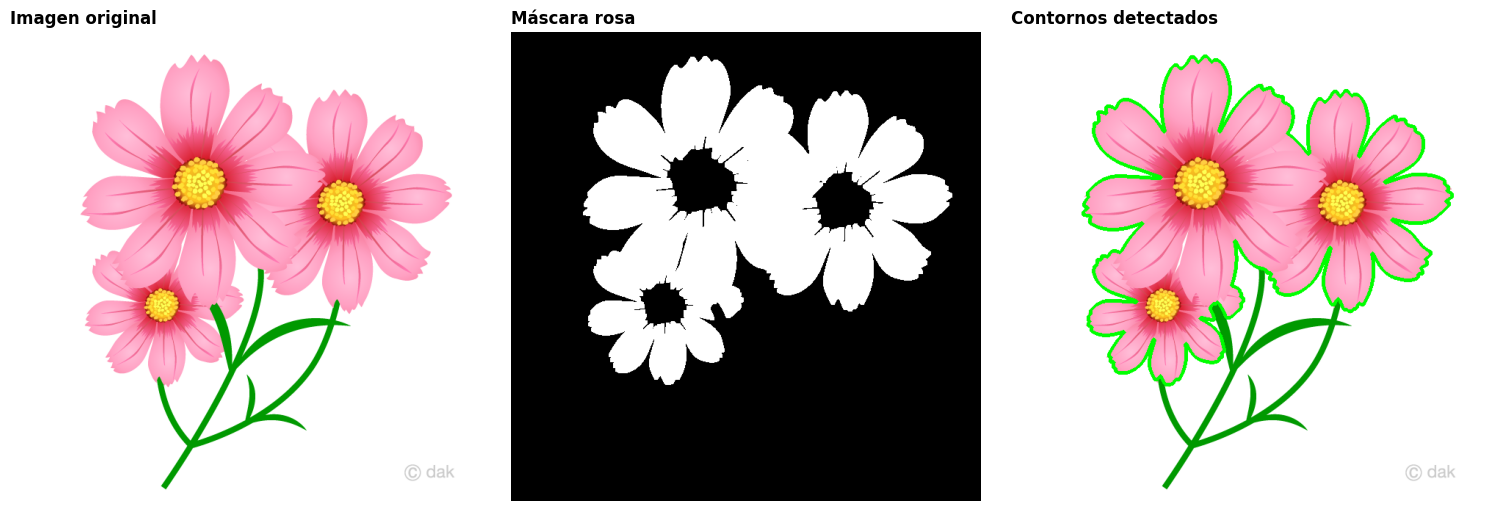

Contornos detectados antes del filtro: 1
Contornos conservados con área mínima 500: 1


In [ ]:
# Cargar la imagen de flores rosadas
ruta_flores = Path("Imagenes") / "flores rosadas.png"
imagen_flores_bgr = cv2.imread(str(ruta_flores), cv2.IMREAD_COLOR)

if imagen_flores_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_flores}")

# Convertir para visualización y segmentación
imagen_flores_rgb = cv2.cvtColor(imagen_flores_bgr, cv2.COLOR_BGR2RGB)
imagen_flores_hsv = cv2.cvtColor(imagen_flores_bgr, cv2.COLOR_BGR2HSV)

# Rango aproximado para rosa
rango_rosa_bajo = np.array([140, 40, 80], dtype=np.uint8)
rango_rosa_alto = np.array([175, 255, 255], dtype=np.uint8)

# Crear máscara
mascara_rosa = cv2.inRange(
    imagen_flores_hsv,
    rango_rosa_bajo,
    rango_rosa_alto
)

# Limpieza morfológica
mascara_rosa = cv2.morphologyEx(
    mascara_rosa,
    cv2.MORPH_OPEN,
    np.ones((5, 5), dtype=np.uint8),
    iterations=1
)

# Buscar contornos
contornos_flores, _ = cv2.findContours(
    mascara_rosa.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Filtrar por área mínima
area_minima = 500
contornos_filtrados_flores = []

for contorno in contornos_flores:
    if cv2.contourArea(contorno) > area_minima:
        contornos_filtrados_flores.append(contorno)

# Dibujar contornos
imagen_con_contornos_flores = imagen_flores_rgb.copy()
cv2.drawContours(imagen_con_contornos_flores, contornos_filtrados_flores, -1, (0, 255, 0), 3)

# Mostrar resultados
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ejes[0].imshow(imagen_flores_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(mascara_rosa, cmap="gray")
ejes[1].set_title("Máscara rosa", fontweight="bold", loc="left")
ejes[1].axis("off")

ejes[2].imshow(imagen_con_contornos_flores)
ejes[2].set_title("Contornos detectados", fontweight="bold", loc="left")
ejes[2].axis("off")

plt.show()

print(f"Contornos detectados antes del filtro: {len(contornos_flores)}")
print(f"Contornos conservados con área mínima {area_minima}: {len(contornos_filtrados_flores)}")


## Cierre

Detectar contornos no es solo llamar a `findContours()`. Antes hace falta una máscara que represente bien el objeto de interés. Cuando esa etapa previa está bien resuelta, el contorno se vuelve una herramienta muy útil para medir, comparar y describir formas.
